In [82]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
def pdie(mu,ni,N_HK):
    """probability of a cell dying"""
    return 1-(1-ni*mu)**N_HK
def pmut(mu,ni,N_I,chroms=2):
    """probability of a cell mutating a not-expressed I gene"""
    return 1-(1-ni*mu)**(chroms*(N_I-ni))

In [84]:
def dp(p,r,d,mu,dt,N_HK,chroms):
    """
    Differential equation for the model
    The system is considered to be at stationarity for reproduction rate and HK genes mutation
    """
    n = len(p)
    ### Variations ###
    dp1 = r*p[0]*(1-p[0])-r*p[0]*pdie(mu,1,N_HK)-r*p[0]*pmut(mu,1,n,chroms)  #1 I gene mutated
    dpi = [ r*p[i]*(1-p[i])+r*p[i-1]*pmut(mu,i,n,chroms)-r*p[i]*pdie(mu,i+1,N_HK)-r*p[i]*pmut(mu,i+1,n,chroms) for i in range(1,n-1)]
    dpn = r*p[-1]*(1-p[-1])+r*p[-2]*pmut(mu,n-1,n,chroms)-r*p[-1]*pdie(mu,n,N_HK) #all I genes mutated
    #dpd = np.sum([r*d*pdie(mu,i+1,n)*p[i] for i in range(n)])-r*p[-1]
    
    dpis = np.concat([[dp1],dpi,[dpn]])
    phi = np.sum(dpis)  # Constant for dilution to keep sum(p)=1
    
    d_tot = np.array([dpis[i]-p[i]*phi for i in range(len(p))])
    return d_tot*dt

In [79]:
counts = np.loadtxt("../Data/CancerEvo/single/counts_full_2.txt", dtype=str, delimiter="?")
counts = [np.array(ci).astype(float) for ci in[c.split(", ") for c in counts[:]]]
for i in range(100):
    counts[i] = np.append(counts[i],[0]*(10-len(counts[i])))
counts = np.array(counts)

In [115]:
mu=0.005
r=0.4
N=10
N_HK=10
chroms=3

### Initial conditions ###
dps=0.02
p_init = [1,0,0,0,0,0,0,0,0,0]#[1-dps*(N-1)]+[dps]*(N-1)
savefig=False
namefig="images/station_mod_3chr.png"

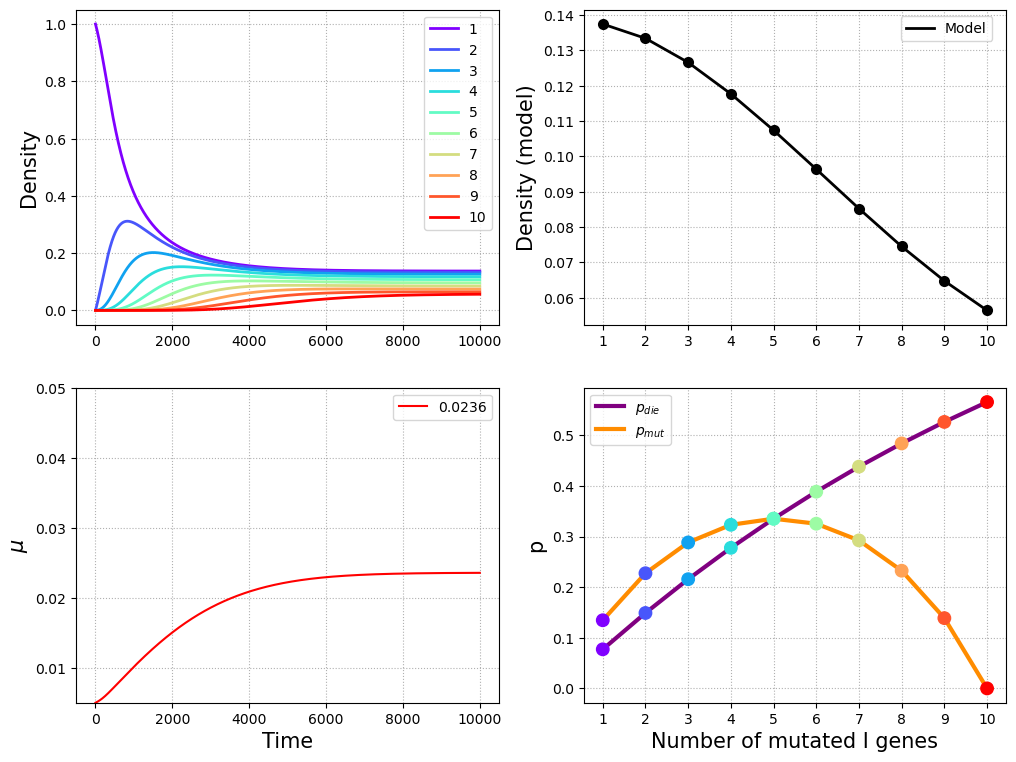

In [119]:
p_list = []
p = np.copy(p_init)
p_list.append(p)

### Simulation ###
dt=0.01
nsteps = 10000
for i in range(nsteps):
    dpi = dp(p,r=r,mu=mu,d=1,dt=dt, N_HK=N_HK, chroms=chroms)
    p = p+dpi
    p_list.append(p)
p_list = np.array(p_list)
### Mu computed over time ###
mu_progr = np.array([np.sum(np.array(p*np.arange(1,N+1))*mu) for p in p_list])

from matplotlib import colormaps


cmap = colormaps.get_cmap("rainbow")
colors = [cmap(i / (N - 1)) for i in range(N)]

### Plots ###
_,ax = plt.subplots(2,2,figsize=(12,9))
ax = ax.flatten()
#ax2 = ax[1].twinx()

for i in range(N):
    ax[0].plot(p_list[:,i],label=str(i+1), c=colors[i], lw=2)
ax[1].plot(np.arange(1,N+1), p_list[-1], color="k", lw=2, label="Model")
ax[1].scatter(np.arange(1,N+1), p_list[-1], color="k", lw=2, zorder=3)
#ax2.plot(np.arange(10)+1, counts[-50], color="blue", label="Data")
#ax2.scatter(np.arange(10)+1, counts[-50], color="blue")
ax[2].plot(mu_progr, color="r", label="%.4f"%(mu_progr[-1]))
ax[2].legend()
ax[3].plot(range(1,N+1), [pdie(0.008,i,N) for i in range(1,N+1)], label=r"$p_{die}$", color="purple", lw=3)
ax[3].scatter(range(1,N+1), [pdie(0.008,i,N) for i in range(1,N+1)], color=colors, zorder=3, s=80)
ax[3].plot(range(1,N+1), [pmut(0.008,i,N) for i in range(1,N+1)], label=r"$p_{mut}$", color="darkorange", lw=3)
ax[3].scatter(range(1,N+1), [pmut(0.008,i,N) for i in range(1,N+1)], color=colors, zorder=3, s=80)
ax[3].legend()
ax[3].set_xticks(np.arange(1,N+1))

ax[0].legend()
#ax[0].set_xlabel("Time", fontsize=15)
ax[0].set_ylabel("Density", fontsize=15)
#ax[1].set_xlabel("Number of mutated I genes", fontsize=15)
ax[1].set_ylabel("Density (model)", fontsize=15)
#ax2.set_ylabel("Density (data)", fontsize=15)
ax[1].legend(loc=(0.75,0.9))
#ax2.legend(loc=(0.75,0.8))
ax[2].set_xlabel("Time", fontsize=15)
ax[1].set_xticks(np.arange(N)+1)
ax[2].set_ylabel(r"$\mu$", fontsize=15)
ax[2].set_ylim([mu, N*mu])
ax[3].set_xlabel("Number of mutated I genes", fontsize=15)
ax[3].set_ylabel("p", fontsize=15)
[axi.grid(ls=":") for axi in ax]
if savefig:
    plt.savefig(namefig)
plt.show()

In [117]:
mu_progr[-1]

np.float64(0.023554459695364568)